<a href="https://colab.research.google.com/github/Pranayshukla0610/Financial-Analyst/blob/main/Fixed_Income_Analytics_%26_Bond_Yield_Prediction_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import yfinance
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings('ignore')

In [3]:
np.random.seed(42)

n = 2000

data = pd.DataFrame({
    'Maturity_years':np.random.randint(1, 31, n),
    'Coupon_Rate':np.random.uniform(1, 12, n),
    'Inflation_Rate':np.random.uniform(2, 8, n),
    'GDP_Growth':np.random.uniform(1, 10, n),
    'Interest_Rate':np.random.uniform(1, 10, n),
    'Credit_Spread':np.random.uniform(0.2, 5, n)
})

In [4]:
data.head()

,Maturity_years,Coupon_Rate,Inflation_Rate,GDP_Growth,Interest_Rate,Credit_Spread
0,7,9.054990,5.849791,8.762407,4.040353,4.158470
1,20,1.036810,6.222754,3.843974,4.492889,1.525369
2,29,6.140418,4.239559,8.669912,3.180640,4.665760
3,15,4.267032,5.381960,1.368405,9.320449,1.950272
4,11,10.381040,4.704119,1.446953,5.695689,4.316770


In [5]:
data['Bond_Yield'] = (
    0.4 * data['Interest_Rate']
    + 0.3 * data['Inflation_Rate']
    + 0.1 * data['Credit_Spread']
    + 0.05 * data['Maturity_years']
    + np.random.normal(0, 0.5, n)
)

##Bond yields generally increase with:

###Higher inflation
###Higher interest rates
###Higher risk
###Longer maturity

In [6]:
data.head()

,Maturity_years,Coupon_Rate,Inflation_Rate,GDP_Growth,Interest_Rate,Credit_Spread,Bond_Yield
0,7,9.054990,5.849791,8.762407,4.040353,4.158470,3.633637
1,20,1.036810,6.222754,3.843974,4.492889,1.525369,4.452663
2,29,6.140418,4.239559,8.669912,3.180640,4.665760,3.435070
3,15,4.267032,5.381960,1.368405,9.320449,1.950272,6.661968
4,11,10.381040,4.704119,1.446953,5.695689,4.316770,5.372319


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Maturity_years  2000 non-null   int64  
 1   Coupon_Rate     2000 non-null   float64
 2   Inflation_Rate  2000 non-null   float64
 3   GDP_Growth      2000 non-null   float64
 4   Interest_Rate   2000 non-null   float64
 5   Credit_Spread   2000 non-null   float64
 6   Bond_Yield      2000 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 109.5 KB


In [8]:
data.describe()

,Maturity_years,Coupon_Rate,Inflation_Rate,GDP_Growth,Interest_Rate,Credit_Spread,Bond_Yield
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,15.722500,6.520447,4.992247,5.442024,5.560993,2.588327,4.762074
std,8.891008,3.185461,1.715053,2.597079,2.622063,1.374781,1.353479
min,1.000000,1.002072,2.001119,1.005648,1.012200,0.200889,0.735289
25%,8.000000,3.687210,3.521779,3.257975,3.358547,1.430612,3.786542
50%,16.000000,6.667327,5.018114,5.443853,5.609433,2.579095,4.762625
75%,23.000000,9.292658,6.487281,7.619205,7.854094,3.745946,5.751061
max,30.000000,11.996852,7.985737,9.998643,9.997671,4.998251,8.348553


In [9]:
data.isnull().sum()

,0
Maturity_years,0
Coupon_Rate,0
Inflation_Rate,0
GDP_Growth,0
Interest_Rate,0
Credit_Spread,0
Bond_Yield,0


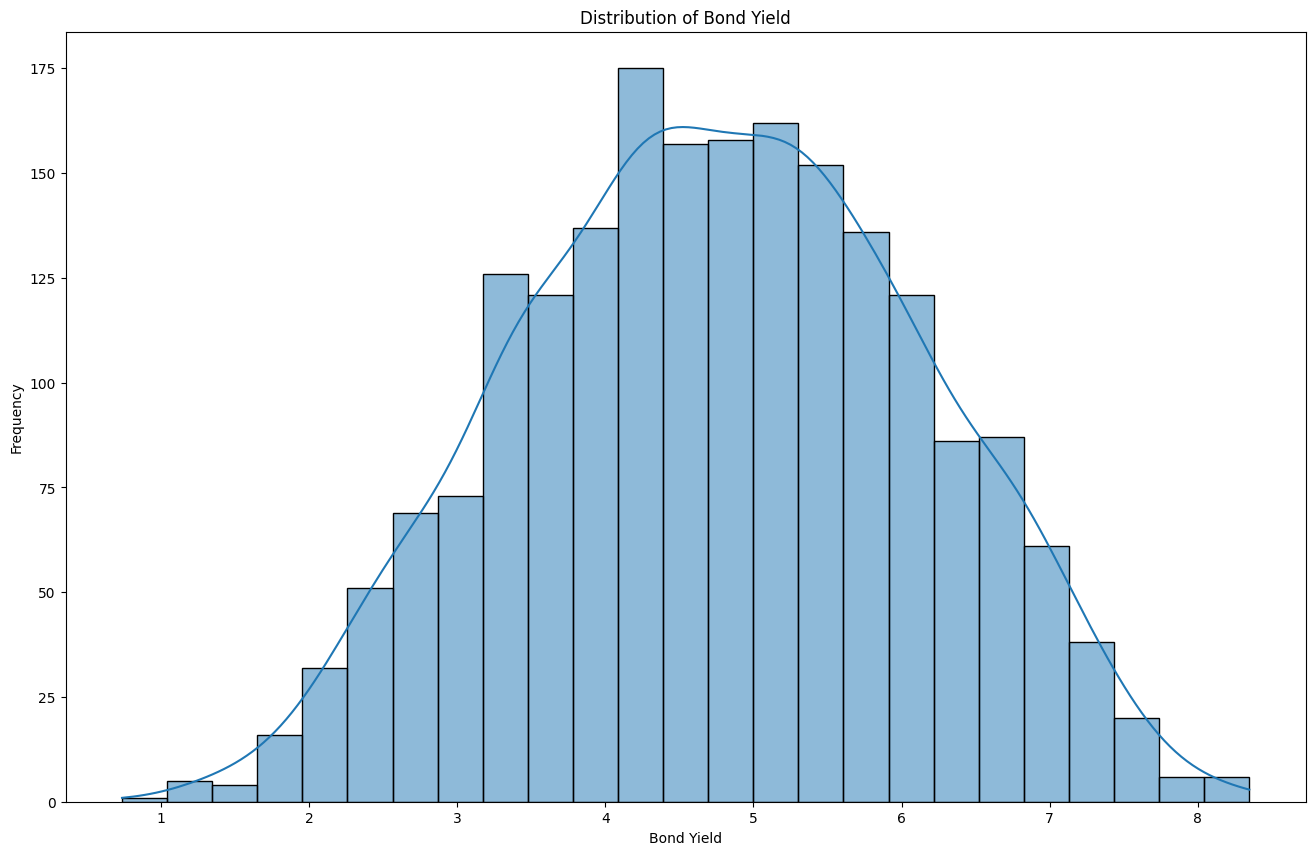

In [10]:
plt.figure(figsize=(16,10))

sns.histplot(data['Bond_Yield'],kde=True)
plt.title('Distribution of Bond Yield')
plt.xlabel('Bond Yield')
plt.ylabel('Frequency')
plt.show()

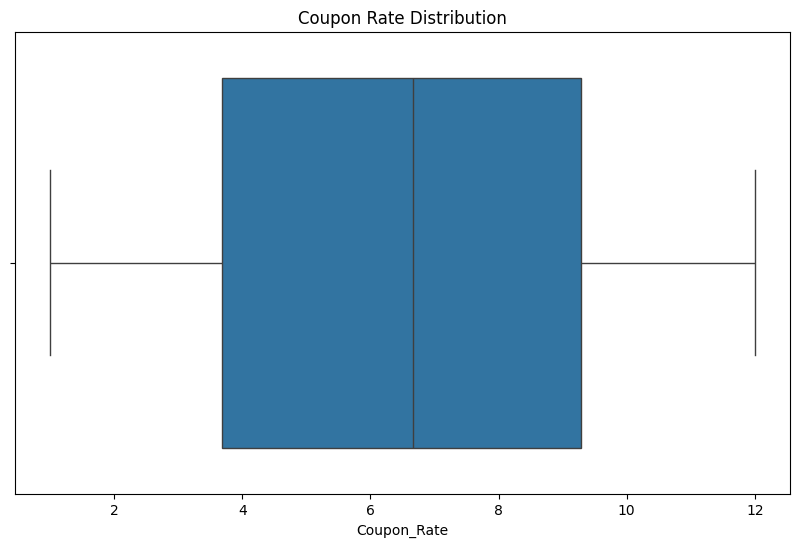

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(x=data['Coupon_Rate'])

plt.title('Coupon Rate Distribution')
plt.show()

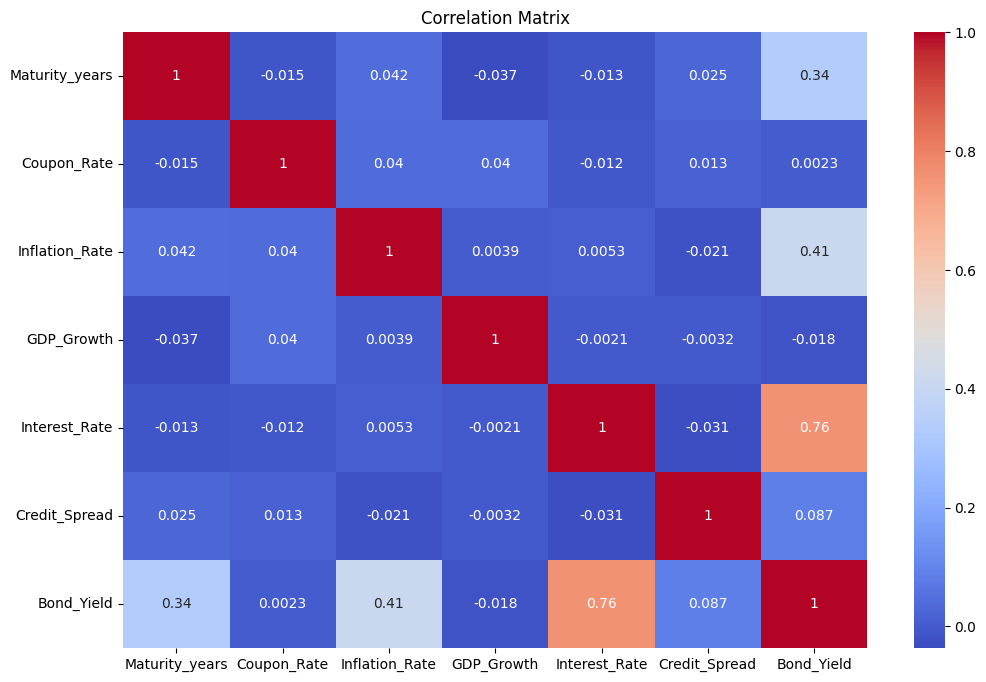

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

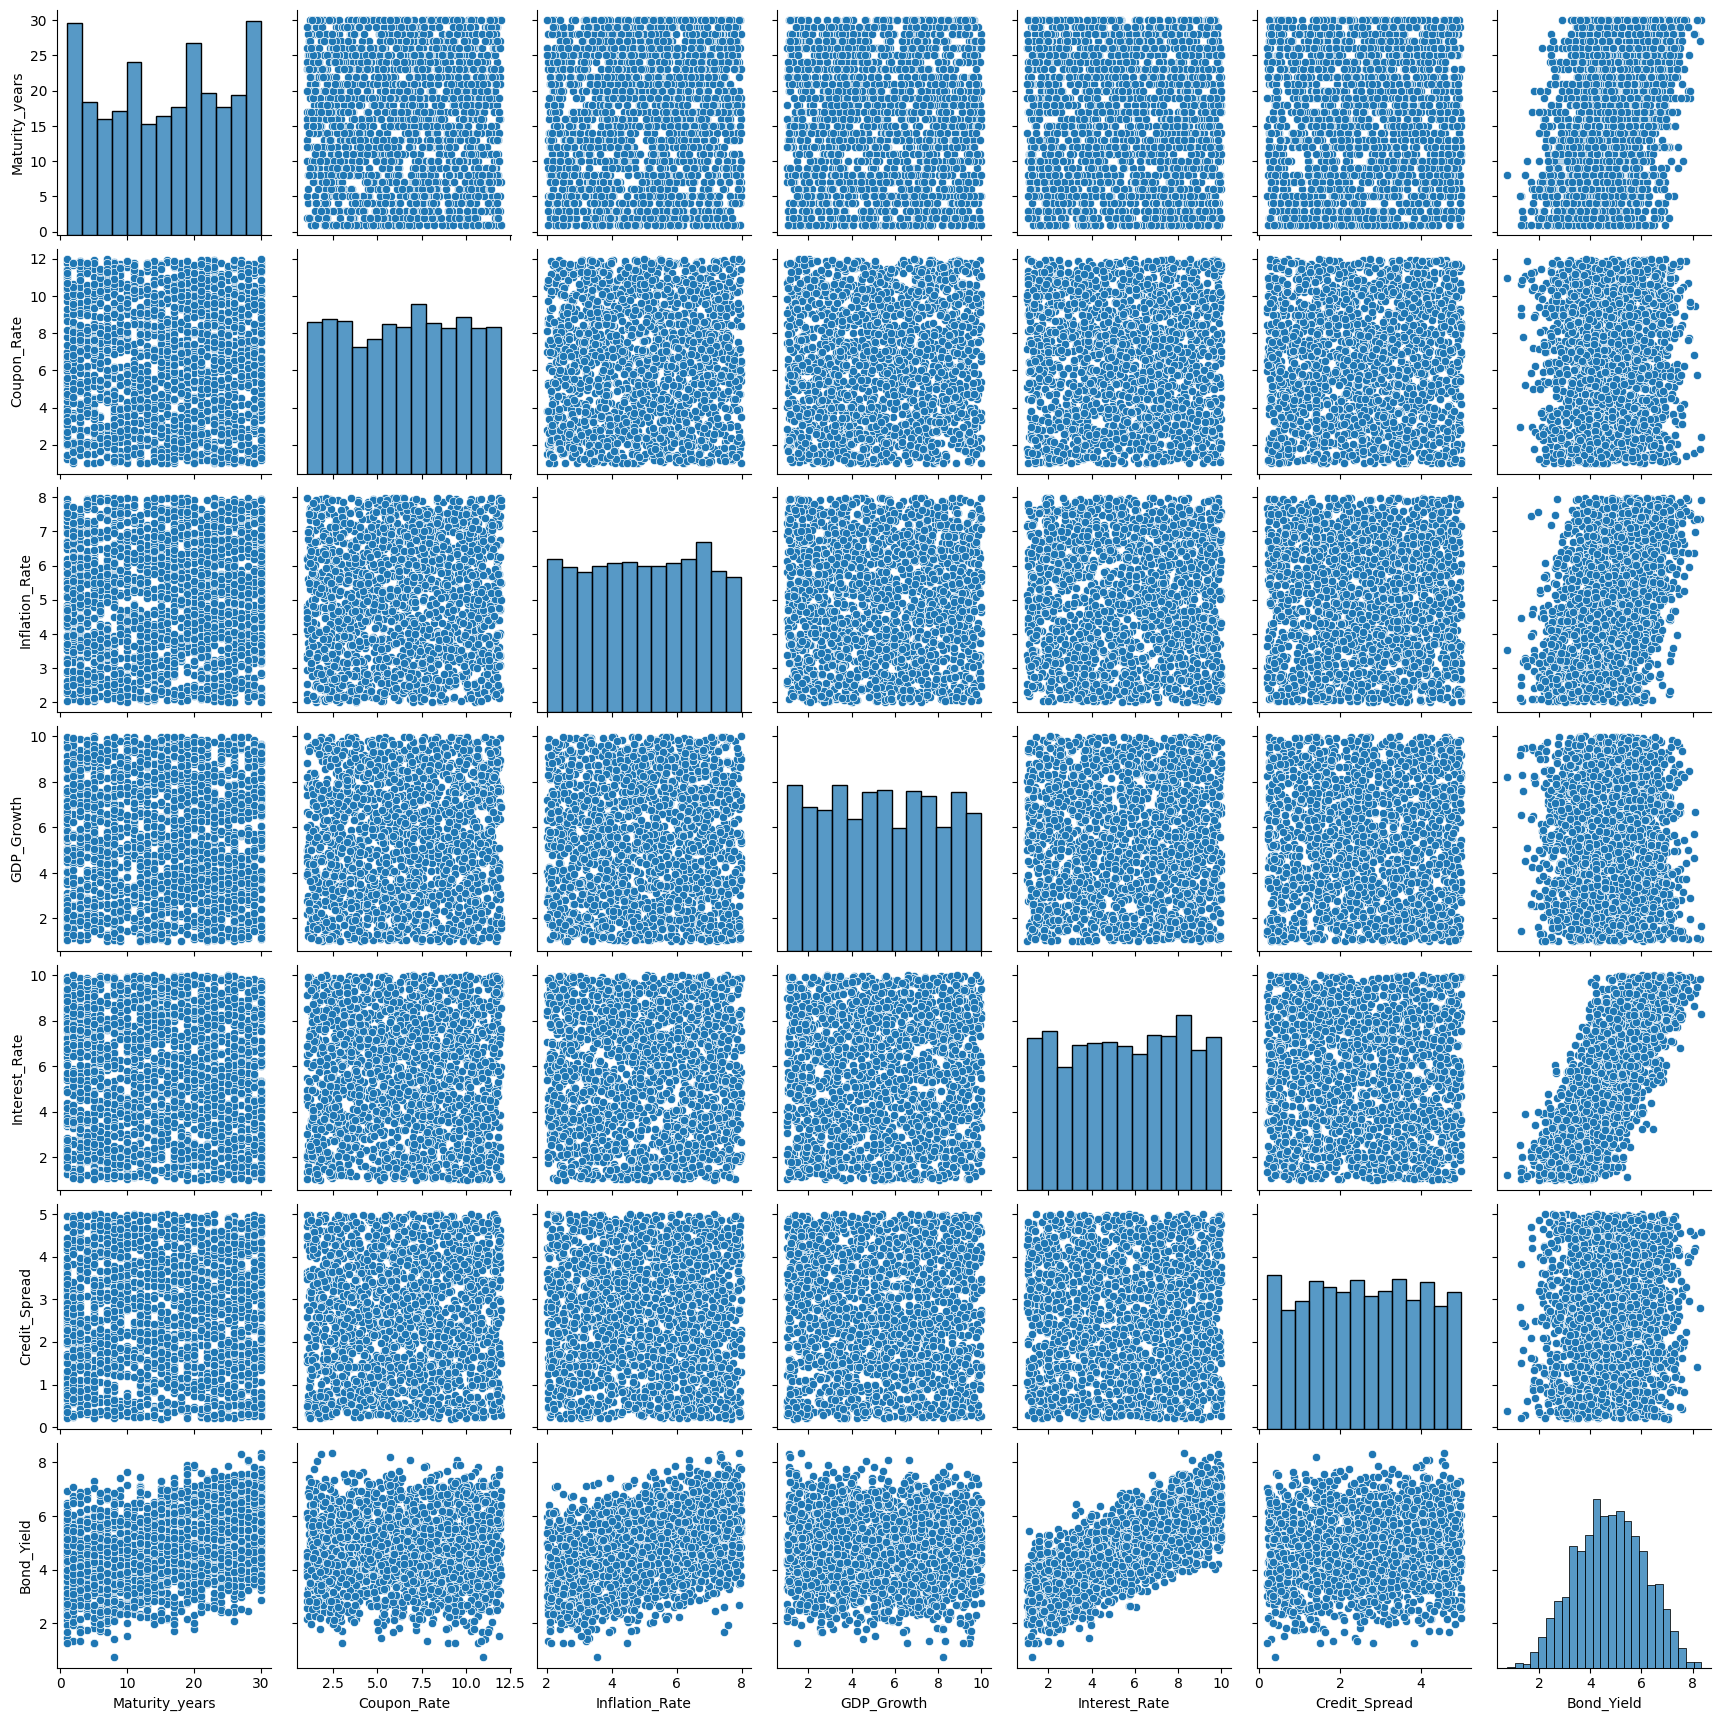

In [14]:
sns.pairplot(data)
plt.show()

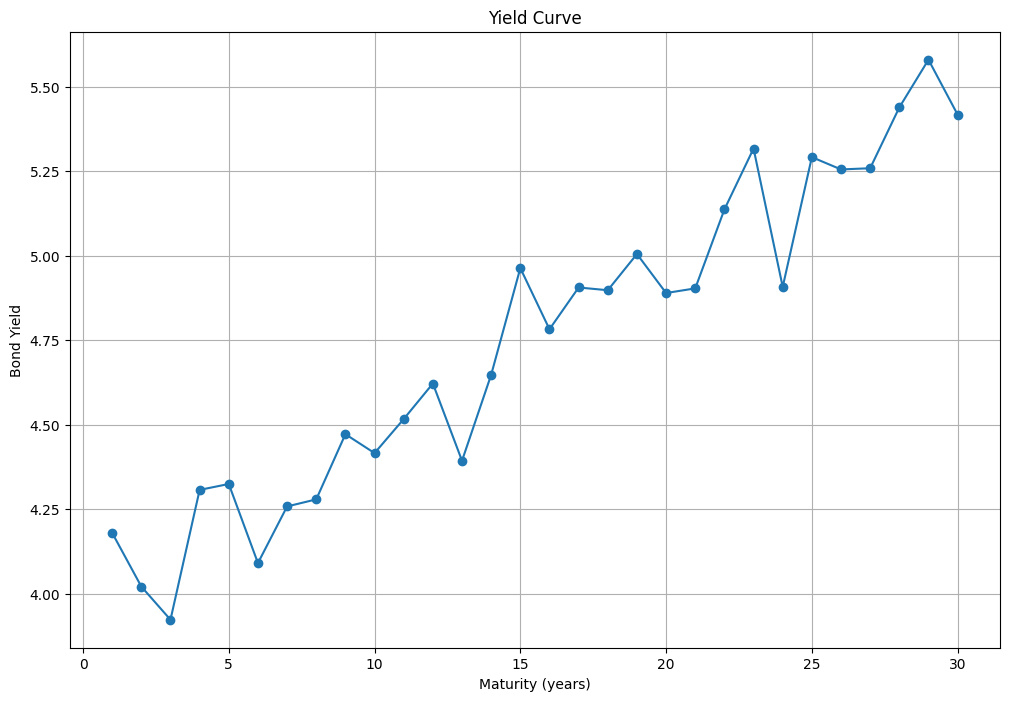

In [15]:
yield_curve = data.groupby('Maturity_years')['Bond_Yield'].mean()

plt.figure(figsize=(12,8))
yield_curve.plot(marker='o')

plt.title('Yield Curve')
plt.xlabel('Maturity (years)')
plt.ylabel('Bond Yield')
plt.grid(True)
plt.show()

In [16]:
data['Duration'] = (
    data['Maturity_years']/
    (1 + data['Bond_Yield']/100)
)

In [17]:
data.head()

,Maturity_years,Coupon_Rate,Inflation_Rate,GDP_Growth,Interest_Rate,Credit_Spread,Bond_Yield,Duration
0,7,9.054990,5.849791,8.762407,4.040353,4.158470,3.633637,6.754564
1,20,1.036810,6.222754,3.843974,4.492889,1.525369,4.452663,19.147430
2,29,6.140418,4.239559,8.669912,3.180640,4.665760,3.435070,28.036912
3,15,4.267032,5.381960,1.368405,9.320449,1.950272,6.661968,14.063119
4,11,10.381040,4.704119,1.446953,5.695689,4.316770,5.372319,10.439174


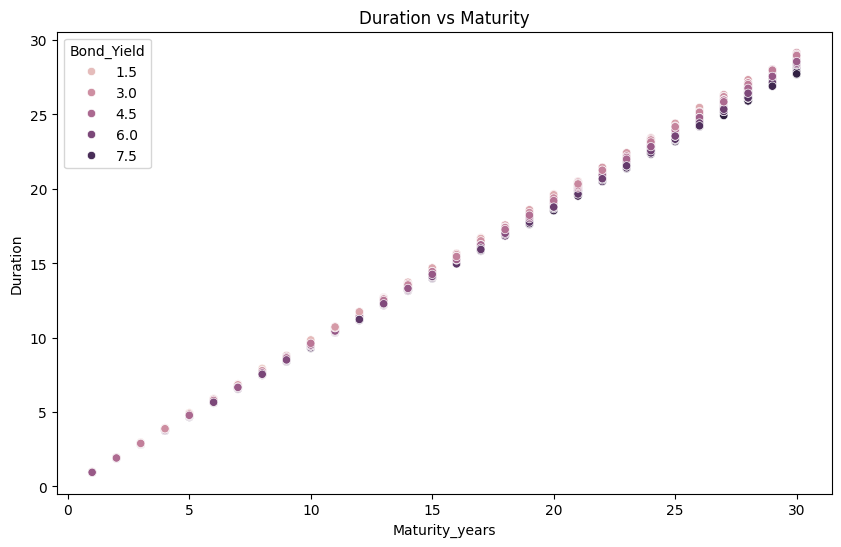

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(x = 'Maturity_years',
                y = 'Duration',
                hue = 'Bond_Yield',
                data = data)

plt.title('Duration vs Maturity')
plt.show()

In [19]:
X = data.drop('Bond_Yield',axis=1)
y = data['Bond_Yield']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
lr = LinearRegression()
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)

In [22]:
print("MAE:", mean_absolute_error(y_test, lr_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score:", r2_score(y_test, lr_pred))

MAE: 0.34531540895171386
RMSE: 0.4446737511654836
R2 Score: 0.8849948643079903


In [23]:
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, n_estimators=200, random_state=42)

In [24]:
rf_pred = rf.predict(X_test)

In [25]:
print("MAE:", mean_absolute_error(y_test, rf_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score:", r2_score(y_test, rf_pred))

MAE: 0.44451351421820456
RMSE: 0.549988564409342
R2 Score: 0.824069326312139


In [26]:
xg = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=8, random_state=42)
xg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [27]:
xg_pred = xg.predict(X_test)

In [29]:
print("MAE:", mean_absolute_error(y_test, xg_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, xg_pred)))

print("R2 Score:", r2_score(y_test, xg_pred))

MAE: 0.4581018829166022
RMSE: 0.5693073190404122
R2 Score: 0.8114928701985968


In [31]:
models = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R2_Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xg_pred)
    ]
})

models

,Model,R2_Score
0,Linear Regression,0.884995
1,Random Forest,0.824069
2,XGBoost,0.811493


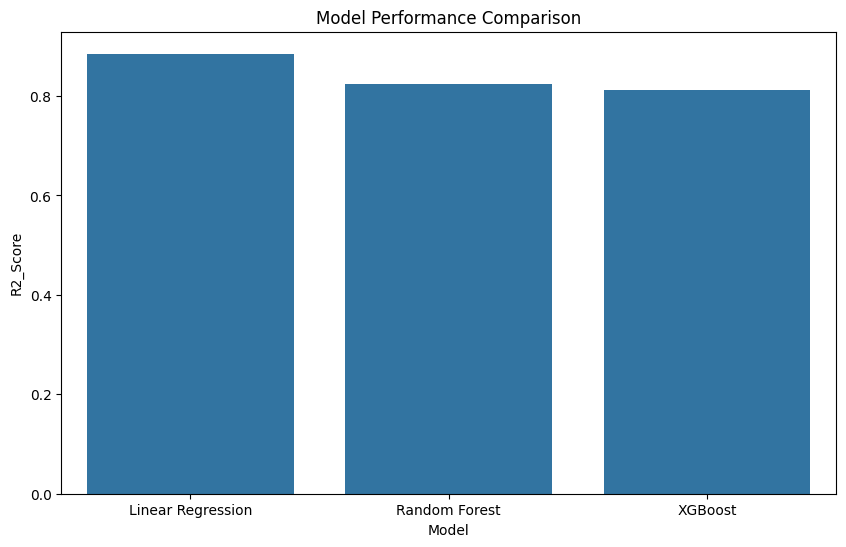

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='R2_Score',
    data=models
)

plt.title('Model Performance Comparison')

plt.show()

In [33]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xg.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
4,Interest_Rate,0.668410
2,Inflation_Rate,0.159050
0,Maturity_years,0.089491
5,Credit_Spread,0.029104
6,Duration,0.021110
3,GDP_Growth,0.017943
1,Coupon_Rate,0.014891


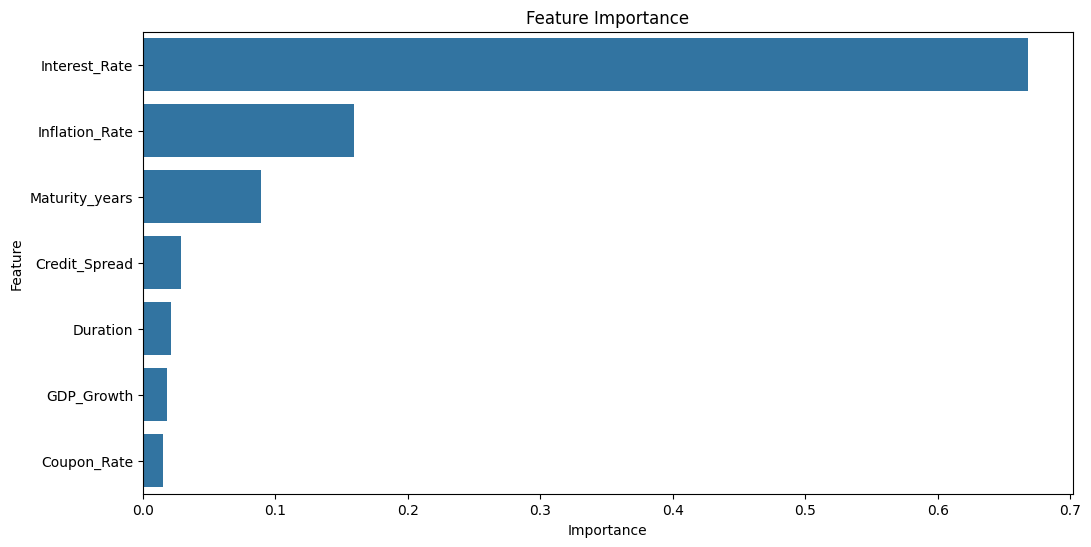

In [34]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

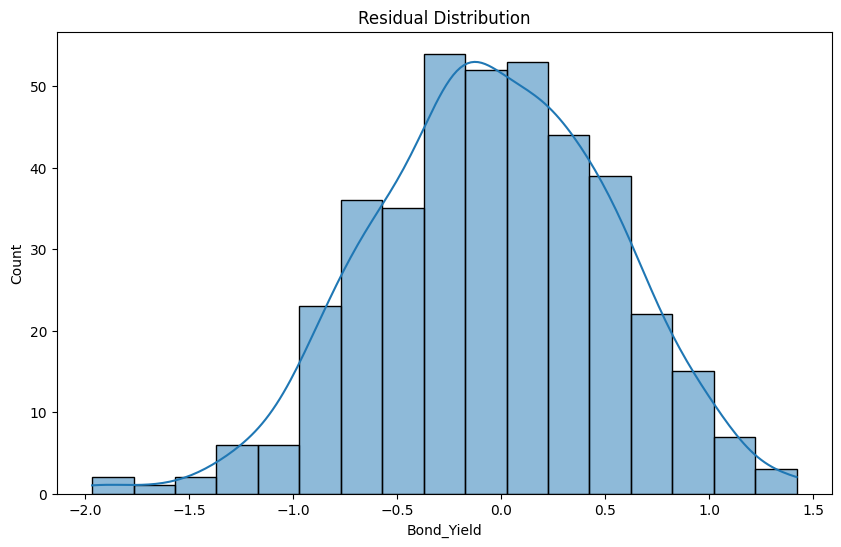

In [36]:
residuals = y_test - xg_pred

plt.figure(figsize=(10,6))

sns.histplot(residuals, kde=True)

plt.title('Residual Distribution')

plt.show()

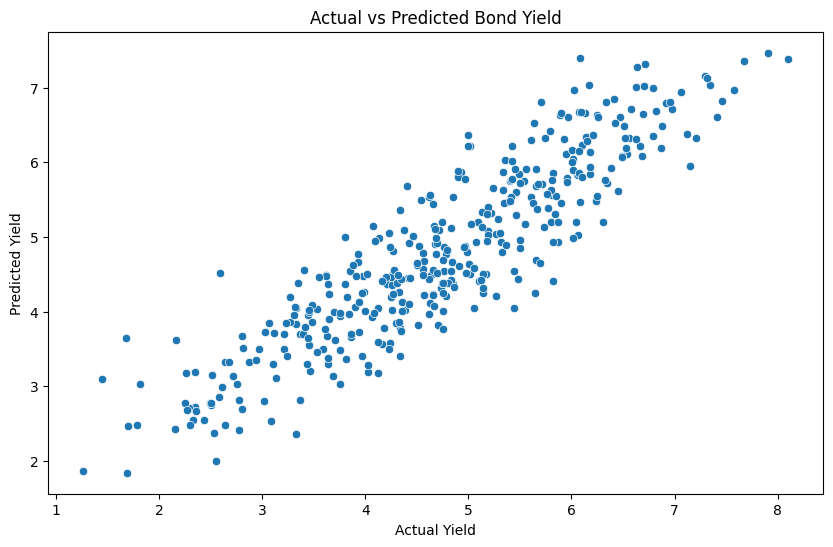

In [38]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=y_test,
    y=xg_pred
)

plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')

plt.title('Actual vs Predicted Bond Yield')

plt.show()

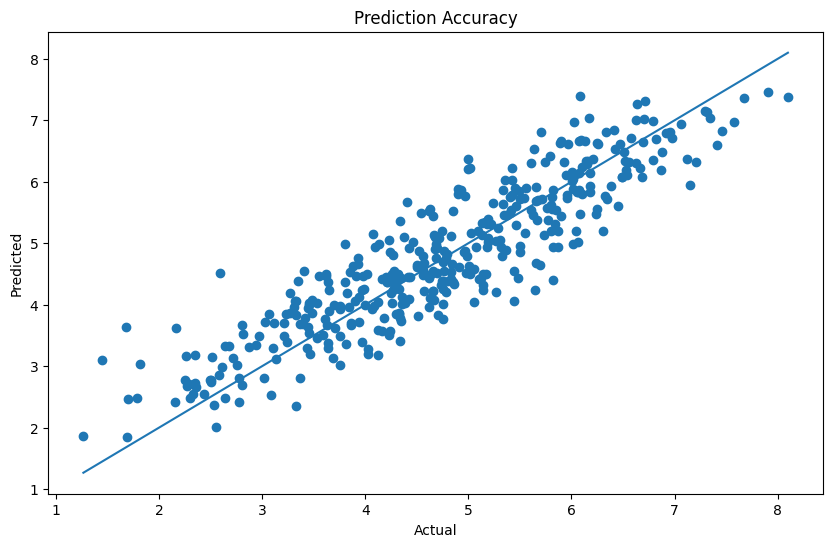

In [39]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, xg_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.title('Prediction Accuracy')

plt.show()